# Libraries

In [659]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [660]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240513 - Ag60 GDE_0.6 M Na2SO4_pH2

11-Aug-26  08:22 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  10:49 PM    <DIR>          .ipynb_checkpoints
14-May-24  10:27 AM            34,067 0p6M_pH2 Na2SO4_20240514_0827_1min - Copy.xlsx
07-Aug-26  02:20 PM            64,679 0p6M_pH2 Na2SO4_20240514_0827_1min.xlsx
14-May-24  10:27 AM           258,896 0p6M_pH2 Na2SO4_20240514_0827_Line_1.csv
19-Jul-25  05:29 PM           915,448 20240513 - Ag60 GDE_0.6 M Na2SO4_pH2.ipynb
11-Aug-26  08:22 AM           783,378 20240513 - Ag60 GDE_0.6 M Na2SO4_pH2_CORRECTED.ipynb
11-Aug-26  08:21 AM               596 20240513_0.6 M Na2SO4_pH2_Energy Consumption.csv
11-Aug-26  07:42 AM             5,592 20240513_0.6M Na2SO4_pH2.csv
11-Aug-26  08:21 AM             1,405 20240513_0.6M Na2SO4_pH2_flow rate.csv
07-Jun-26  03:12 PM           138,114 

# Load Data

In [661]:
Book = "Book_20240513 - Ag60 GDE_0.6 M Na2SO4_pH2.xlsx" #normalized
# Book =  "Book_20240513 - Ag60 GDE_0.6 M Na2SO4_pH2_Norm.xlsx" # Normalize concentration
Book = pd.read_excel(Book)
Book.tail(10)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),Unnamed: 19,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 25
30,Ag60 GDE in PTFE holder,60.0,73.542618,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.1,2024-05-14 05:59:00,13.583333,15.625657,...,0.058045,0.779299,0.009400,0.998885,0.705180,0.269039,NaN,0.974219,0.069320,85.999159
31,Ag60 GDE in PTFE holder,60.0,73.755414,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-14 06:25:00,14.016667,15.930648,...,0.055985,0.778899,0.009467,0.998895,0.486649,0.176293,NaN,0.662942,0.067057,NaN
32,Ag60 GDE in PTFE holder,60.0,83.954513,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-14 06:52:00,14.466667,23.252121,...,0.054022,0.706711,0.012644,0.998847,0.808175,0.193635,NaN,1.001810,0.071013,78.451968
33,Ag60 GDE in PTFE holder,60.0,83.559996,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-14 07:18:00,14.900000,23.528359,...,0.053820,0.703532,0.012964,0.998859,0.815337,0.192004,NaN,1.007341,0.071063,NaN
34,Ag60 GDE in PTFE holder,60.0,84.190240,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-14 07:45:00,15.350000,23.757896,...,0.054365,0.700242,0.013599,0.998862,0.829083,0.195412,NaN,1.024494,0.072044,77.725402
35,Ag60 GDE in PTFE holder,60.0,83.851128,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-14 08:11:00,15.783333,23.999695,...,0.053201,0.699047,0.013714,0.998860,0.833766,0.190460,NaN,1.024225,0.070723,NaN
36,Ag60 GDE in PTFE holder,60.0,68.465356,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-14 08:43:00,16.316667,12.912247,...,0.052168,0.813005,0.007725,0.998820,2.282096,0.945443,NaN,3.227539,0.060297,88.716373
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,12.643766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,12.797108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,10.448869,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [662]:
# NOTE: do NOT rescale the Excel FE columns here.
# The old "FE * 100" line caused totals > 300% whenever this cell was
# re-run, and we recompute FE from scratch further down anyway.
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),Unnamed: 19,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 25
0,Ag60 GDE in PTFE holder,60.0,55.635079,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.00,2024-05-13 16:24:00,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
1,Ag60 GDE in PTFE holder,60.0,57.953270,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 16:42:00,0.3,0.640681,...,0.007796,0.984813,0.001127,0.999979,0.368332,0.459995,NaN,0.828327,0.007854,NaN
2,Ag60 GDE in PTFE holder,60.0,57.801727,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 17:18:00,0.9,0.766896,...,0.007604,0.984177,0.000761,0.999985,0.438017,0.447469,NaN,0.885486,0.007667,102.185993


In [663]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),Unnamed: 19,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 25,GC_flow_rate_ml_min
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,12.643766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,12.797108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,10.448869,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Temp from pH meter

In [664]:
Temp = "2024-05-14_102826.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.992792792792795
Temp C median: 24.0


## Power Supply

In [665]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.tail(5)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
12982,40.00V,8.77V,1.500A,1.495A,320.00W,13.11W,NaN,NaN,NaN,On,CC,NaN,14.05.2024 10:27:14.623
12983,40.00V,8.66V,1.500A,1.494A,320.00W,12.93W,NaN,NaN,NaN,On,CC,NaN,14.05.2024 10:27:19.638
12984,40.00V,8.90V,1.500A,1.490A,320.00W,13.26W,NaN,NaN,NaN,On,CC,NaN,14.05.2024 10:27:24.637
12985,40.00V,8.98V,1.500A,1.494A,320.00W,13.41W,NaN,NaN,NaN,On,CC,NaN,14.05.2024 10:27:29.644
12986,40.00V,9.01V,1.500A,1.495A,320.00W,13.46W,NaN,NaN,NaN,On,CC,NaN,14.05.2024 10:27:30.256


In [666]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.20V
0.100A 1    3.08V
       2    3.15V

In [667]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-05-13 16:00:00     0.107      3.44
1 2024-05-13 18:00:00     0.261      4.44
2 2024-05-13 20:00:00     0.513      5.84
3 2024-05-13 22:00:00     0.758      7.10
4 2024-05-14 00:00:00     1.003      8.10
5 2024-05-14 02:00:00     1.503      9.72
6 2024-05-14 04:00:00     1.999     11.25
7 2024-05-14 06:00:00     2.998     14.28
8 2024-05-14 08:00:00     2.999     13.99
9 2024-05-14 10:00:00     1.501      9.29


In [668]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-2].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-13 16:00:00     0.107      3.44
1 2024-05-13 18:00:00     0.261      4.44
2 2024-05-13 20:00:00     0.513      5.84
3 2024-05-13 22:00:00     0.758      7.10
4 2024-05-14 00:00:00     1.003      8.10
5 2024-05-14 02:00:00     1.503      9.72
6 2024-05-14 04:00:00     1.999     11.25
7 2024-05-14 06:00:00     2.998     14.28


In [669]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [670]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.107,3.44
0.261,4.44
0.513,5.84
0.758,7.10
1.003,8.10
1.503,9.72
1.999,11.25
2.998,14.28


In [671]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.107,3.44,1.07
0.261,4.44,2.61
0.513,5.84,5.13
0.758,7.10,7.58
1.003,8.10,10.03
1.503,9.72,15.03
1.999,11.25,19.99
2.998,14.28,29.98


## Flow rate

In [672]:
flow_rate = "0p6M_pH2 Na2SO4_20240514_0827_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-14 08:27:24.854000,NaN
1,Software version,Aurora 1.0.2,NaN
2,Instrument name,0p6M_pH2 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6e:f2:c4,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [673]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-13 14:24:00,55.635079,27.817539
1,2024-05-13 14:24:59.962000,55.620684,27.810342
2,2024-05-13 14:26:00.010000,56.298362,28.149181
3,2024-05-13 14:26:59.971000,56.780623,28.390312
4,2024-05-13 14:28:00.019000,57.347758,28.673879
...,...,...,...
1011,2024-05-14 07:14:59.971000,69.723668,34.861834
1012,2024-05-14 07:16:00.019000,70.037768,35.018884
1013,2024-05-14 07:16:59.981000,69.30475,34.652375
1014,2024-05-14 07:18:00.029000,70.390827,35.195414


In [674]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

# # print(flow_rate)
# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

### Correction for dry flow

In [675]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.382 L/mol
p_sat = 2.9845 kPa -> x(H2O) = 2.95 % -> dry factor 0.97055


In [676]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [677]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-13 14:00:00     55.620684     59.685886      57.772046   
1 2024-05-13 16:00:00     57.355149     59.555709      58.347774   
2 2024-05-13 18:00:00     57.827438     60.257284      58.969664   
3 2024-05-13 20:00:00     58.654104     62.021237      60.715541   
4 2024-05-13 22:00:00     60.771524     65.686931      63.662154   
5 2024-05-14 00:00:00     64.026581     69.957485      68.204059   
6 2024-05-14 02:00:00     68.256017     75.070322      73.015529   
7 2024-05-14 04:00:00     73.545635     85.528114      81.999346   
8 2024-05-14 06:00:00     67.392403     84.542265      73.498584   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0         57.85488         53.982399         57.927862          56.070393   
1        58.332696         55.665776         57.801519          56.629164   
2        58.982953         56.124154          58.48243          57.232736   
3        60

In [678]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
# dfflow_rate = dfflow_rate*0.9723
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-13 14:00:00,55.620684,59.685886,57.772046,57.85488,53.982399,57.927862,56.070393,56.150788,0.107,3.44
1,2024-05-13 16:00:00,57.355149,59.555709,58.347774,58.332696,55.665776,57.801519,56.629164,56.61453,0.261,4.44
2,2024-05-13 18:00:00,57.827438,60.257284,58.969664,58.982953,56.124154,58.48243,57.232736,57.245634,0.513,5.84
3,2024-05-13 20:00:00,58.654104,62.021237,60.715541,60.950186,56.926471,60.194426,58.927189,59.154923,0.758,7.10
4,2024-05-13 22:00:00,60.771524,65.686931,63.662154,64.215735,58.981523,63.752149,61.78701,62.324287,1.003,8.10
5,2024-05-14 00:00:00,64.026581,69.957485,68.204059,69.070189,62.140704,67.896915,66.195136,67.035754,1.503,9.72
6,2024-05-14 02:00:00,68.256017,75.070322,73.015529,73.82217,66.245563,72.859156,70.864886,71.647767,1.999,11.25
7,2024-05-14 04:00:00,73.545635,85.528114,81.999346,83.901736,71.379378,83.008917,79.584088,81.430443,2.998,14.28


In [681]:
# dfflow_rate.to_csv('20240513_0.6M Na2SO4_pH2_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [682]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.107,3.44,1.07,107.0
0.261,4.44,2.61,261.0
0.513,5.84,5.13,513.0


In [683]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.107,3.44,1.07,107.0,2650.176
0.261,4.44,2.61,261.0,8343.648
0.513,5.84,5.13,513.0,21570.624
0.758,7.10,7.58,758.0,38748.960
1.003,8.10,10.03,1003.0,58494.960
1.503,9.72,15.03,1503.0,105185.952
1.999,11.25,19.99,1999.0,161919.000
2.998,14.28,29.98,2998.0,308242.368


In [684]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.107,3.44,1.07,107.0,2650.176,0.000736
0.261,4.44,2.61,261.0,8343.648,0.002318
0.513,5.84,5.13,513.0,21570.624,0.005992
0.758,7.10,7.58,758.0,38748.960,0.010764
1.003,8.10,10.03,1003.0,58494.960,0.016249
1.503,9.72,15.03,1503.0,105185.952,0.029218
1.999,11.25,19.99,1999.0,161919.000,0.044977
2.998,14.28,29.98,2998.0,308242.368,0.085623


In [687]:
# dfcell_voltage.to_csv('20240513_0.6 M Na2SO4_pH2_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [688]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),Unnamed: 19,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 25,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60.0,55.64,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.00,2024-05-13 16:24:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,55.64,0.0
1,Ag60 GDE in PTFE holder,60.0,57.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 16:42:00,0.30,0.640681,...,0.001127,0.999979,0.368332,0.459995,NaN,0.828327,0.007854,NaN,57.95,0.0
2,Ag60 GDE in PTFE holder,60.0,57.80,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 17:18:00,0.90,0.766896,...,0.000761,0.999985,0.438017,0.447469,NaN,0.885486,0.007667,102.185993,57.80,0.0
3,Ag60 GDE in PTFE holder,60.0,59.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 17:52:00,1.47,0.801503,...,0.000619,0.999985,0.468378,0.437726,NaN,0.906104,0.007334,NaN,59.12,1.0
4,Ag60 GDE in PTFE holder,60.0,58.51,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 18:19:00,1.92,0.831424,...,0.000599,0.999987,0.482414,0.406783,NaN,0.889197,0.006888,101.775574,58.51,1.0
5,Ag60 GDE in PTFE holder,60.0,58.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 18:55:00,2.52,0.574816,...,0.000503,0.999983,0.160256,0.735769,NaN,0.896025,0.025906,NaN,58.30,2.0
6,Ag60 GDE in PTFE holder,60.0,58.52,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 19:23:00,2.98,0.596798,...,0.000448,0.999985,0.166861,0.726404,NaN,0.893265,0.025481,101.961223,58.52,2.0
7,Ag60 GDE in PTFE holder,60.0,58.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 19:48:00,3.40,0.617063,...,0.000441,0.999984,0.172951,0.725912,NaN,0.898864,0.025423,NaN,58.63,3.0
8,Ag60 GDE in PTFE holder,60.0,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 20:16:00,3.87,0.642138,...,0.000413,0.999985,0.178666,0.719262,NaN,0.897928,0.025378,101.861478,58.21,3.0
9,Ag60 GDE in PTFE holder,60.0,58.84,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.52,2024-05-13 20:41:00,4.28,1.186615,...,0.001367,0.999983,0.173251,0.670278,NaN,0.843529,0.045342,NaN,58.84,4.0


## Current Density

In [689]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,Unnamed: 19,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 25,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60.0,55.64,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.00,2024-05-13 16:24:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,55.64,0.0,0.0
1,Ag60 GDE in PTFE holder,60.0,57.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 16:42:00,0.30,0.640681,...,0.999979,0.368332,0.459995,NaN,0.828327,0.007854,NaN,57.95,0.0,-130.0
2,Ag60 GDE in PTFE holder,60.0,57.80,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 17:18:00,0.90,0.766896,...,0.999985,0.438017,0.447469,NaN,0.885486,0.007667,102.185993,57.80,0.0,-130.0
3,Ag60 GDE in PTFE holder,60.0,59.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 17:52:00,1.47,0.801503,...,0.999985,0.468378,0.437726,NaN,0.906104,0.007334,NaN,59.12,1.0,-130.0
4,Ag60 GDE in PTFE holder,60.0,58.51,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.13,2024-05-13 18:19:00,1.92,0.831424,...,0.999987,0.482414,0.406783,NaN,0.889197,0.006888,101.775574,58.51,1.0,-130.0
5,Ag60 GDE in PTFE holder,60.0,58.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 18:55:00,2.52,0.574816,...,0.999983,0.160256,0.735769,NaN,0.896025,0.025906,NaN,58.30,2.0,-270.0
6,Ag60 GDE in PTFE holder,60.0,58.52,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 19:23:00,2.98,0.596798,...,0.999985,0.166861,0.726404,NaN,0.893265,0.025481,101.961223,58.52,2.0,-270.0
7,Ag60 GDE in PTFE holder,60.0,58.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 19:48:00,3.40,0.617063,...,0.999984,0.172951,0.725912,NaN,0.898864,0.025423,NaN,58.63,3.0,-270.0
8,Ag60 GDE in PTFE holder,60.0,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.27,2024-05-13 20:16:00,3.87,0.642138,...,0.999985,0.178666,0.719262,NaN,0.897928,0.025378,101.861478,58.21,3.0,-270.0
9,Ag60 GDE in PTFE holder,60.0,58.84,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.52,2024-05-13 20:41:00,4.28,1.186615,...,0.999983,0.173251,0.670278,NaN,0.843529,0.045342,NaN,58.84,4.0,-520.0


## FE(CO)

In [690]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [691]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.45       # gas temperature at the meter       [K]  (~23.3 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.382 L/mol


In [692]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.107, 0.261, 0.513, 0.758, 1.003, 1.503, 1.999, 2.998]

In [693]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[5, 4, 4, 5, 4, 5, 4, 5]

In [694]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))

                     c(H2)  c(CO)
Applied current / A              
0.107                0.007  0.007
0.261                0.006  0.025
0.513                0.013  0.047
0.758                0.029  0.058
1.003                0.053  0.061
1.503                0.102  0.062
1.999                0.149  0.060
2.998                0.229  0.054


In [695]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 104.2 / 90.3 %


In [696]:
rows = rows.drop(rows[rows['FE(total)'] > 102].index) #Noise in the first measurements
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
0,Ag60 GDE in PTFE holder,60.0,55.64,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-13 16:24:00,0.00,0.000000,...,55.64,0.0,-107.0,0.00,0.107,56.070393,53.982399,57.927862,56.150788,0.000000
1,Ag60 GDE in PTFE holder,60.0,57.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-13 16:42:00,0.30,0.640681,...,57.95,0.0,-107.0,0.13,0.107,56.070393,53.982399,57.927862,56.150788,97.179885
5,Ag60 GDE in PTFE holder,60.0,58.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 18:55:00,2.52,0.574816,...,58.30,2.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.716169
6,Ag60 GDE in PTFE holder,60.0,58.52,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 19:23:00,2.98,0.596798,...,58.52,2.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.092160
7,Ag60 GDE in PTFE holder,60.0,58.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 19:48:00,3.40,0.617063,...,58.63,3.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.489490
8,Ag60 GDE in PTFE holder,60.0,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 20:16:00,3.87,0.642138,...,58.21,3.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,90.045167
9,Ag60 GDE in PTFE holder,60.0,58.84,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 20:41:00,4.28,1.186615,...,58.84,4.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,82.904713
10,Ag60 GDE in PTFE holder,60.0,59.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 21:09:00,4.75,1.289524,...,59.47,4.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,87.077757
11,Ag60 GDE in PTFE holder,60.0,59.33,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 21:34:00,5.17,1.322673,...,59.33,5.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,88.107805
12,Ag60 GDE in PTFE holder,60.0,58.73,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 22:02:00,5.63,1.363966,...,58.73,5.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,88.053085


In [697]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
33,Ag60 GDE in PTFE holder,60.0,83.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.998,2024-05-14 06:52:00,14.47,23.252121,...,83.95,14.0,-2998.0,3.1,2.998,79.584088,71.379378,83.008917,81.430443,100.137206
34,Ag60 GDE in PTFE holder,60.0,83.56,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.998,2024-05-14 07:18:00,14.90,23.528359,...,83.56,14.0,-2998.0,3.1,2.998,79.584088,71.379378,83.008917,81.430443,101.165377


In [698]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.05].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.05].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.02].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60.0,57.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-13 16:42:00,0.30,0.640681,...,57.95,0.0,-107.0,0.13,0.107,56.070393,53.982399,57.927862,56.150788,97.179885
5,Ag60 GDE in PTFE holder,60.0,58.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 18:55:00,2.52,0.574816,...,58.30,2.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.716169
6,Ag60 GDE in PTFE holder,60.0,58.52,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 19:23:00,2.98,0.596798,...,58.52,2.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.092160
7,Ag60 GDE in PTFE holder,60.0,58.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 19:48:00,3.40,0.617063,...,58.63,3.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.489490
8,Ag60 GDE in PTFE holder,60.0,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 20:16:00,3.87,0.642138,...,58.21,3.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,90.045167
9,Ag60 GDE in PTFE holder,60.0,58.84,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 20:41:00,4.28,1.186615,...,58.84,4.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,82.904713
10,Ag60 GDE in PTFE holder,60.0,59.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 21:09:00,4.75,1.289524,...,59.47,4.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,87.077757
11,Ag60 GDE in PTFE holder,60.0,59.33,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 21:34:00,5.17,1.322673,...,59.33,5.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,88.107805
12,Ag60 GDE in PTFE holder,60.0,58.73,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 22:02:00,5.63,1.363966,...,58.73,5.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,88.053085
13,Ag60 GDE in PTFE holder,60.0,61.70,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.758,2024-05-13 23:48:00,7.40,3.050428,...,61.70,7.0,-758.0,0.76,0.758,58.927189,56.926471,60.194426,59.154923,90.597958


### Mean FE per current density

In [699]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        107   43.212958   53.966927     43.212958     53.966927        NaN   
1        261   16.955934   72.629812     16.930516     72.360309   0.399873   
2        513   18.543188   67.992652     18.786959     68.517903   0.548551   
3        758   30.341013   60.016946     30.279858     60.118225   0.508427   
4       1003   43.691578   50.197699     43.814091     50.397169   1.281074   
5       1503   60.387566   36.524145     60.654620     36.423555   0.863432   
6       1999   70.340098   28.174297     70.616172     28.310719   0.793622   
7       2998   81.332450   19.318841     81.332450     19.318841   0.550313   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0        NaN        NaN        NaN  43.212958  ...   0.006243     0.006243  1   
1   0.352991   0.799746   0.705981  16.493198  ...   0.005926     0.005917  4   
2   0.716736   1.097102   1.433473  18.149808

## FE(H2)

In [700]:
print(rows["FE(H2)"])

1     43.212958
5     16.045927
6     16.642288
7     17.218744
8     17.916779
9     17.027655
10    18.523859
11    19.050060
12    19.571178
13    30.627893
14    29.931823
15    31.594805
17    29.209532
18    40.630063
19    42.728207
20    44.899974
21    46.508067
22    62.125750
23    60.098314
24    61.210926
26    58.115273
27    68.198553
28    70.233287
29    70.999057
30    71.929496
33    80.782137
34    81.882763
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

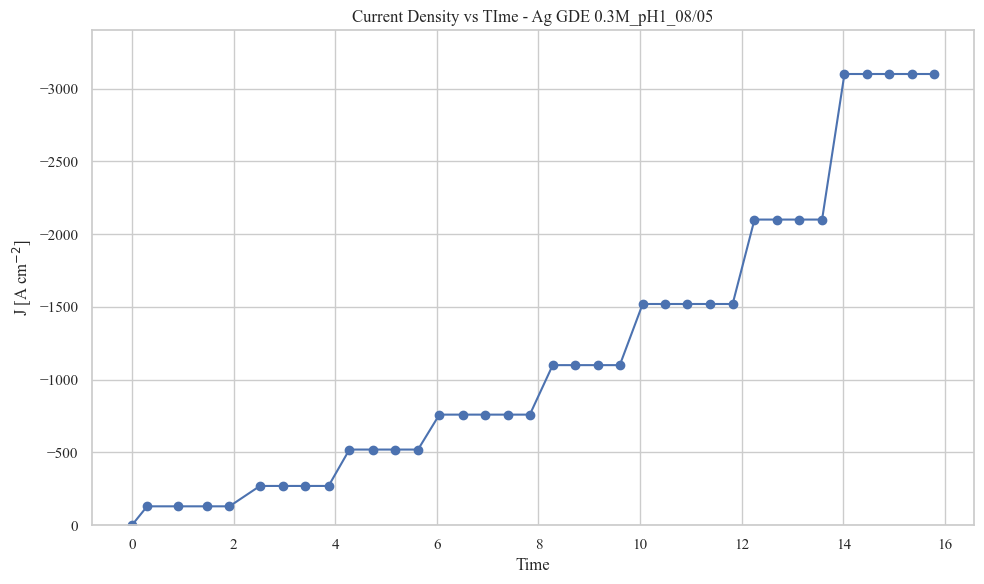

In [701]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

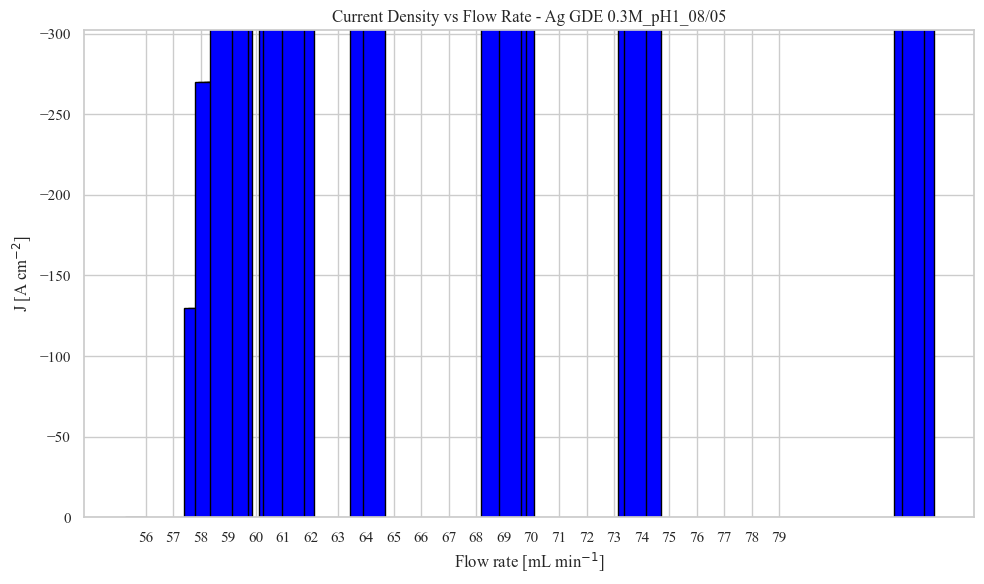

In [702]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Current Density'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -302)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


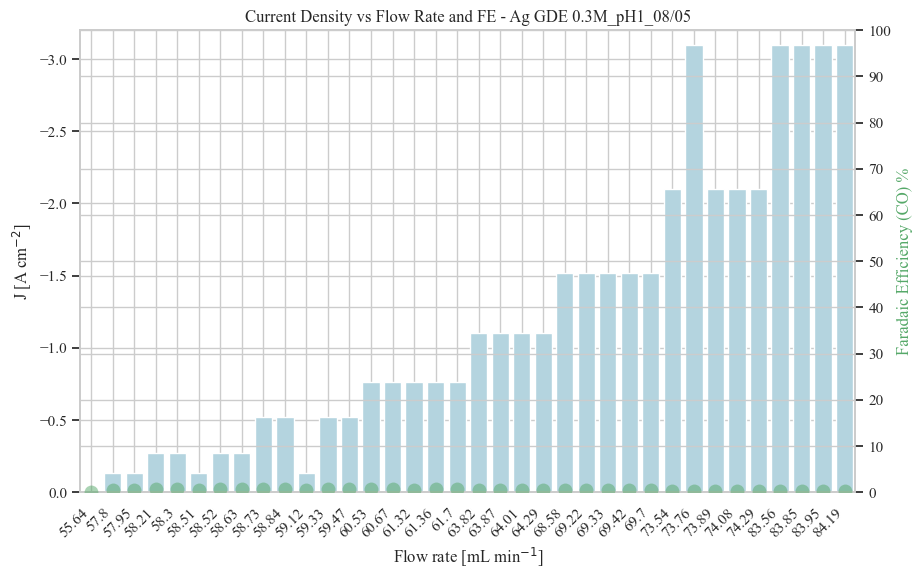

In [703]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH1_08/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [704]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [705]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240513 - Ag60 GDE_0.6 M Na2SO4_pH2

11-Aug-26  08:22 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  10:49 PM    <DIR>          .ipynb_checkpoints
14-May-24  10:27 AM            34,067 0p6M_pH2 Na2SO4_20240514_0827_1min - Copy.xlsx
07-Aug-26  02:20 PM            64,679 0p6M_pH2 Na2SO4_20240514_0827_1min.xlsx
14-May-24  10:27 AM           258,896 0p6M_pH2 Na2SO4_20240514_0827_Line_1.csv
19-Jul-25  05:29 PM           915,448 20240513 - Ag60 GDE_0.6 M Na2SO4_pH2.ipynb
11-Aug-26  08:22 AM           783,378 20240513 - Ag60 GDE_0.6 M Na2SO4_pH2_CORRECTED.ipynb
11-Aug-26  08:24 AM               596 20240513_0.6 M Na2SO4_pH2_Energy Consumption.csv
11-Aug-26  07:42 AM             5,592 20240513_0.6M Na2SO4_pH2.csv
11-Aug-26  08:24 AM             1,405 20240513_0.6M Na2SO4_pH2_flow rate.csv
07-Jun-26  03:12 PM           138,114 

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


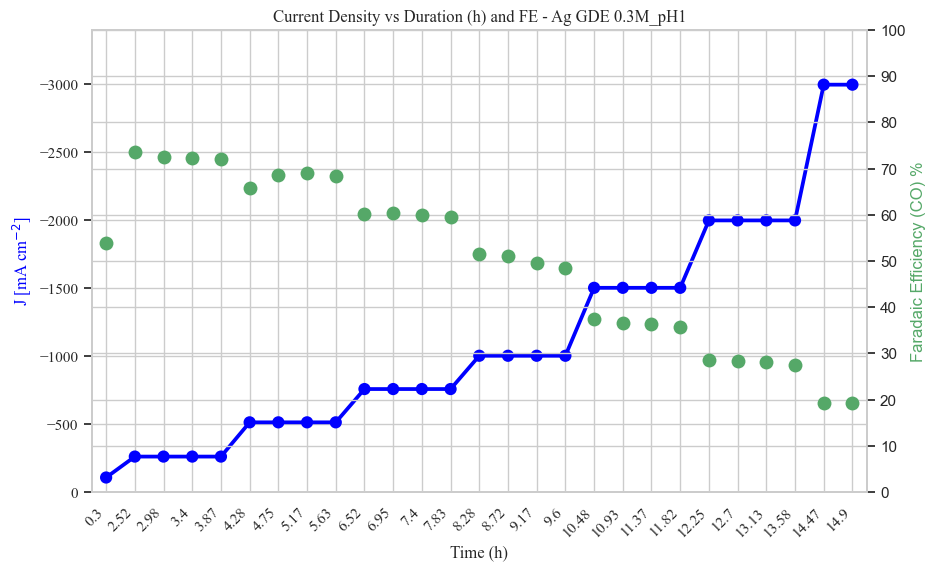

In [706]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points form initail step in each current

In [707]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.05].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.05].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.02].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60.0,57.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-05-13 16:42:00,0.30,0.640681,...,57.95,0.0,-107.0,0.13,0.107,56.070393,53.982399,57.927862,56.150788,97.179885
5,Ag60 GDE in PTFE holder,60.0,58.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 18:55:00,2.52,0.574816,...,58.30,2.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.716169
6,Ag60 GDE in PTFE holder,60.0,58.52,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 19:23:00,2.98,0.596798,...,58.52,2.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.092160
7,Ag60 GDE in PTFE holder,60.0,58.63,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 19:48:00,3.40,0.617063,...,58.63,3.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,89.489490
8,Ag60 GDE in PTFE holder,60.0,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.261,2024-05-13 20:16:00,3.87,0.642138,...,58.21,3.0,-261.0,0.27,0.261,56.629164,55.665776,57.801519,56.61453,90.045167
9,Ag60 GDE in PTFE holder,60.0,58.84,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 20:41:00,4.28,1.186615,...,58.84,4.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,82.904713
10,Ag60 GDE in PTFE holder,60.0,59.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 21:09:00,4.75,1.289524,...,59.47,4.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,87.077757
11,Ag60 GDE in PTFE holder,60.0,59.33,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 21:34:00,5.17,1.322673,...,59.33,5.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,88.107805
12,Ag60 GDE in PTFE holder,60.0,58.73,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.513,2024-05-13 22:02:00,5.63,1.363966,...,58.73,5.0,-513.0,0.52,0.513,57.232736,56.124154,58.48243,57.245634,88.053085
13,Ag60 GDE in PTFE holder,60.0,61.70,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.758,2024-05-13 23:48:00,7.40,3.050428,...,61.70,7.0,-758.0,0.76,0.758,58.927189,56.926471,60.194426,59.154923,90.597958


## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

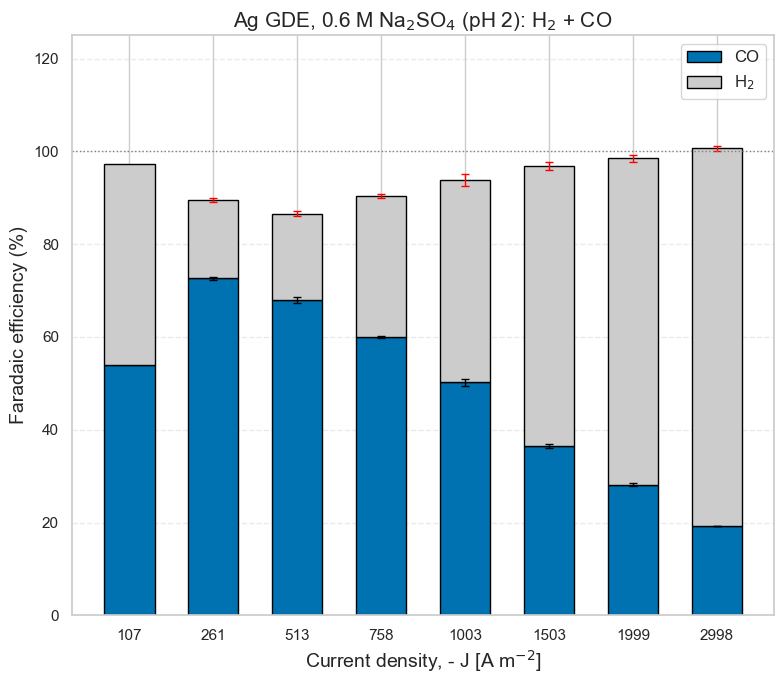

In [708]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M Na$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

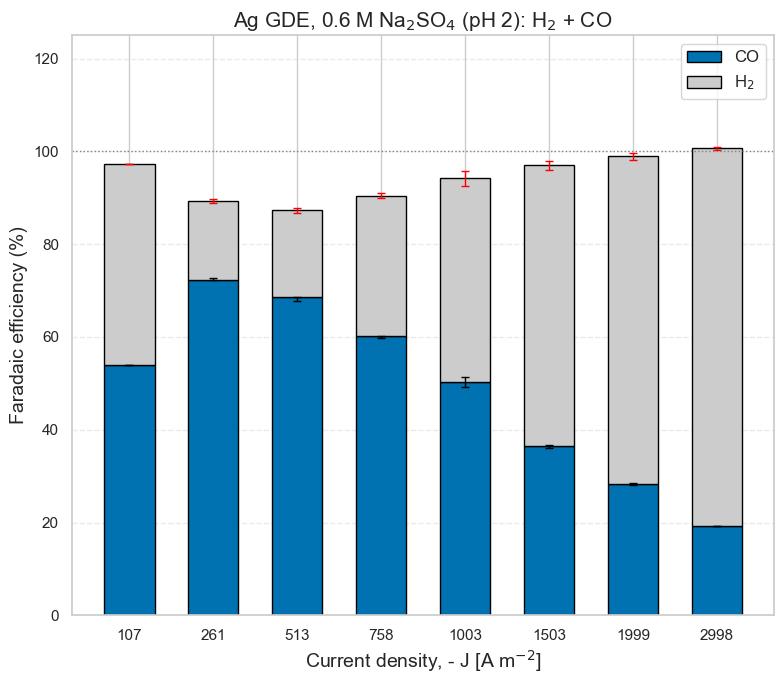

In [711]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M Na$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [712]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [713]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,43.212958,53.966927,43.212958,53.966927,0.000000,0.000000,0.000000,0.000000,43.212958,...,0.006243,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0–2,107
1,250,16.955934,72.629812,16.930516,72.360309,0.399873,0.352991,0.799746,0.705981,16.493198,...,0.005917,4,0.437318,0.462737,0.125152,0.394655,0.212672,0.195589,2–4,261
2,500,18.543188,67.992652,18.786959,68.517903,0.548551,0.716736,1.097102,1.433473,18.149808,...,0.012763,4,0.637152,0.393380,0.687208,0.161957,1.530925,0.501344,4–6,513
3,750,30.341013,60.016946,30.279858,60.118225,0.508427,0.214054,1.016854,0.428109,29.751250,...,0.029415,4,0.528608,0.589763,0.282292,0.181012,0.347595,0.241765,6–8,758
4,1000,43.691578,50.197699,43.814091,50.397169,1.281074,0.712241,2.562147,1.424482,42.203671,...,0.053455,4,1.610420,1.487907,1.078899,0.879429,0.730991,0.409008,8–10,1003
5,1500,60.387566,36.524145,60.654620,36.423555,0.863432,0.355551,1.726865,0.711102,59.602554,...,0.103097,4,1.052066,0.785012,0.260962,0.361552,0.690515,0.524050,10–12,1503
6,2000,70.340098,28.174297,70.616172,28.310719,0.793622,0.258308,1.587245,0.516616,69.724603,...,0.149364,4,0.891568,0.615495,0.286510,0.150089,0.741480,0.328984,12–14,1999
7,3000,81.332450,19.318841,81.332450,19.318841,0.550313,0.036227,0.778260,0.051233,81.057293,...,0.227007,2,0.275156,0.275156,0.018114,0.018114,0.257043,0.257043,14–16,2998


In [716]:
Res_Book
# Res_Book.to_csv('20240513_0.6M Na2SO4_pH2.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,43.212958,53.966927,43.212958,53.966927,0.000000,0.000000,0.000000,0.000000,43.212958,...,0.006243,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0–2,107
1,250,16.955934,72.629812,16.930516,72.360309,0.399873,0.352991,0.799746,0.705981,16.493198,...,0.005917,4,0.437318,0.462737,0.125152,0.394655,0.212672,0.195589,2–4,261
2,500,18.543188,67.992652,18.786959,68.517903,0.548551,0.716736,1.097102,1.433473,18.149808,...,0.012763,4,0.637152,0.393380,0.687208,0.161957,1.530925,0.501344,4–6,513
3,750,30.341013,60.016946,30.279858,60.118225,0.508427,0.214054,1.016854,0.428109,29.751250,...,0.029415,4,0.528608,0.589763,0.282292,0.181012,0.347595,0.241765,6–8,758
4,1000,43.691578,50.197699,43.814091,50.397169,1.281074,0.712241,2.562147,1.424482,42.203671,...,0.053455,4,1.610420,1.487907,1.078899,0.879429,0.730991,0.409008,8–10,1003
5,1500,60.387566,36.524145,60.654620,36.423555,0.863432,0.355551,1.726865,0.711102,59.602554,...,0.103097,4,1.052066,0.785012,0.260962,0.361552,0.690515,0.524050,10–12,1503
6,2000,70.340098,28.174297,70.616172,28.310719,0.793622,0.258308,1.587245,0.516616,69.724603,...,0.149364,4,0.891568,0.615495,0.286510,0.150089,0.741480,0.328984,12–14,1999
7,3000,81.332450,19.318841,81.332450,19.318841,0.550313,0.036227,0.778260,0.051233,81.057293,...,0.227007,2,0.275156,0.275156,0.018114,0.018114,0.257043,0.257043,14–16,2998


## Mean and StD of FE(CO) through time

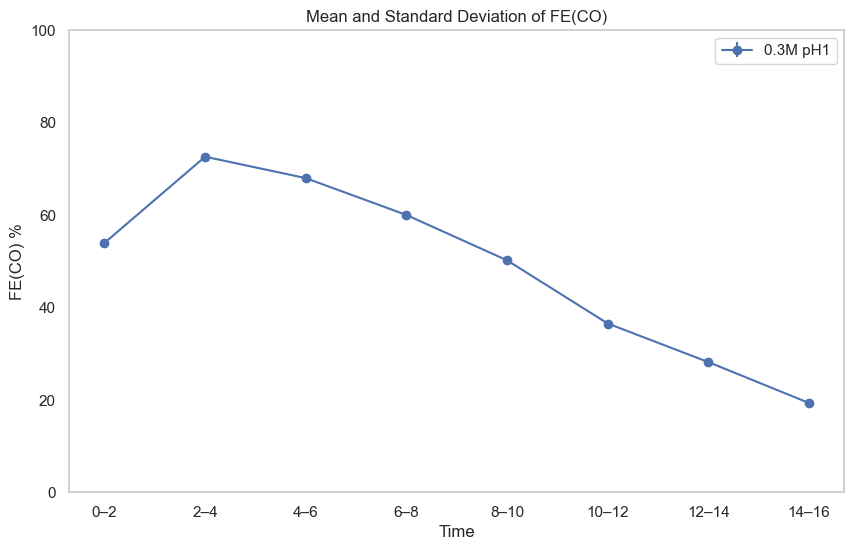

In [717]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.3M pH1')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240508_0.3M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

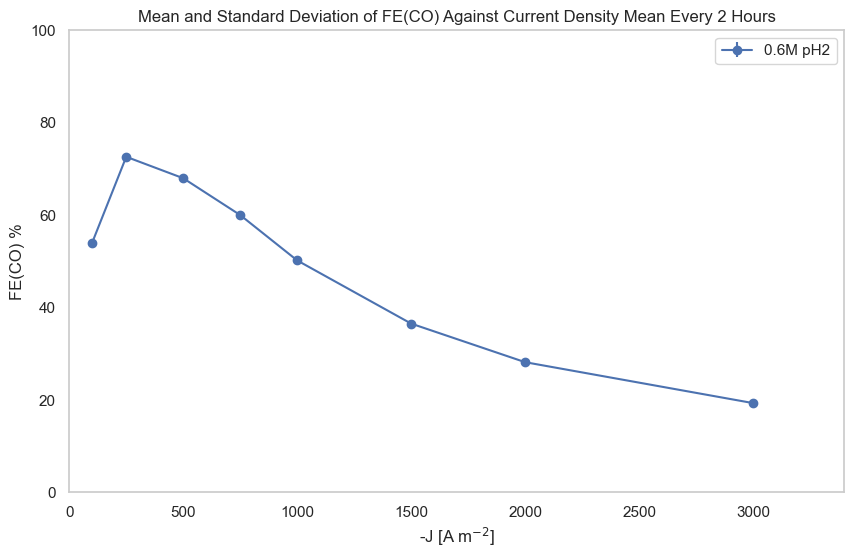

In [718]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M pH2')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.6M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()

In [719]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot FE (CO) mean with standard deviation against Applied Current mean
# ax.errorbar(Res_Book['Current Density_mean'], Res_Book['FE(H2)_mean'], 
#             yerr=Res_Book['FE(H2)_std'], fmt='-o', label='0.6M pH2')

# # Formatting the plot
# ax.set_xlabel(r'-J [A m$^{-2}$]')
# ax.set_ylabel('FE(H2) %')
# ax.set_xlim(0,340)
# ax.set_ylim(0,140)
# ax.set_title('Mean and Standard Deviation of FE(H2) Against Current Density Mean Every 2 Hours')
# ax.legend()
# ax.grid(False)

# # plt.savefig('20240508_0.3M_pH1_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
# plt.show()